In [19]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Available GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
Built with CUDA: False
Available GPUs: []


In [ ]:
!pip install tensorflow==2.15.0


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.preprocessing import LabelBinarizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
from bs4 import BeautifulSoup
import re,string,unicodedata
from keras.preprocessing import  sequence
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
from string import punctuation
from nltk import pos_tag
from nltk.corpus import wordnet
import keras
from keras.models import Sequential
from keras.layers import Dense,Embedding,LSTM,Dropout
from keras.callbacks import ReduceLROnPlateau
import tensorflow as tf
from keras.layers import Bidirectional
from sklearn.metrics import roc_curve, auc
import json


In [4]:
stop_words = set(stopwords.words('arabic'))

In [5]:
dataset_dir = "data/AFND/Dataset"

# This file contains information about the credibility of each source (credible, not credible, undecided).
sources_file_path = 'data/AFND/sources.json'
with open(sources_file_path, 'r', encoding='utf-8') as sources_file:
    sources_data = json.load(sources_file)

# Convert the sources data into a DataFrame for easier processing
sources_df = pd.DataFrame(list(sources_data.items()), columns=['source', 'label'])


In [6]:
# This is where the articles from each source are stored. We'll iterate over each source to load its articles.
import os
articles_data = []
for source in sources_df['source']:
    scraped_articles_path = os.path.join(dataset_dir, source, 'scraped_articles.json')
    
    # Check if the file exists before attempting to read it
    if os.path.exists(scraped_articles_path):
        with open(scraped_articles_path, 'r', encoding='utf-8') as articles_file:
            source_articles_dict = json.load(articles_file)
            source_articles_list = source_articles_dict.get("articles", [])
            # Add a 'source' key to each article to keep track of where it came from
            for article in source_articles_list:
                article['source'] = source
            
            # Add all articles to the main list
            articles_data.extend(source_articles_list)

# Convert articles_data to a DataFrame for processing
articles_df = pd.DataFrame(articles_data)

In [9]:
# This merges the article data with the credibility label from the sources data.
df = pd.merge(articles_df, sources_df, how='inner', left_on='source', right_on='source')

# Optional: Display the first few rows and the shape of the merged DataFrame
df.head()
df.shape

(606912, 5)

Text(0, 0.5, '# of Articles')

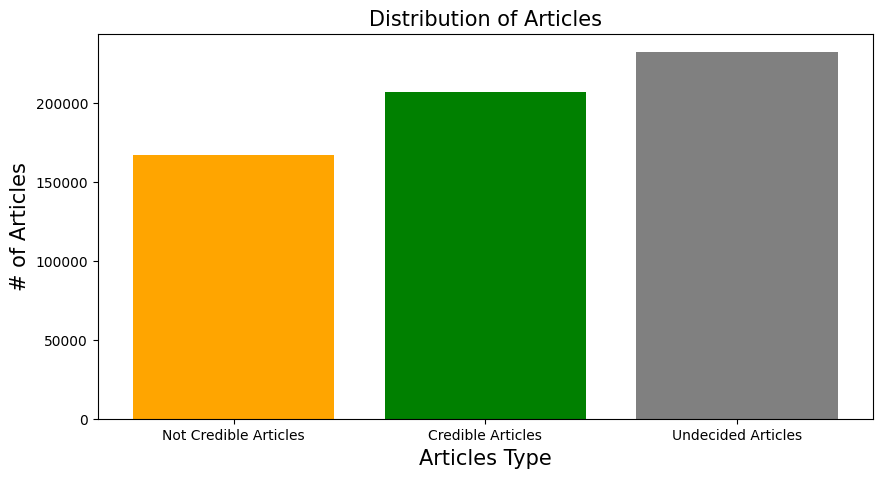

In [10]:
plt.figure(figsize=(10, 5))
plt.bar('Not Credible Articles', len(df[df['label'] == 'not credible']), color='orange')
plt.bar('Credible Articles', len(df[df['label'] == 'credible']), color='green')
plt.bar('Undecided Articles', len(df[df['label'] == 'undecided']), color='gray')
plt.title('Distribution of Articles', size=15)
plt.xlabel('Articles Type', size=15)
plt.ylabel('# of Articles', size=15)

In [11]:
df

,title,text,published date,source,label
0,المنتخب الوطني المغربي لأقل من 20 سنة يخوض تجم...,يخوض المنتخب الوطني المغربي لكرة القدم لأقل من...,2021-05-23T00:00:00,source_1,credible
1,وزير النقل اعمارة:السرعة عامل مسبب لحوادث السي...,ترأس عبد القادر اعمارة، وزير التجهيز و النقل و...,2021-05-22T00:00:00,source_1,credible
2,"ميسي يؤكد أن الفوز بكأس اسبانيا كان ""نقطة تحول""",أكد النجم الارجنتيني ليونيل ميسي أن فوز فريقه ...,2021-05-22T00:00:00,source_1,credible
3,دبلوماسي مغربي سابق بإسبانيا لـ2M.ma: خطأ مدري...,أكّد الدبلوماسي المغربي السابق بإسبانيا، عبد ا...,2021-05-22T00:00:00,source_1,credible
4,شركتان، فرنسية وبريطانية تعلنان عن نتائج إيجاب...,أعلنت شركتا سانوفي الفرنسية العملاقة في تصنيع ...,2021-05-17T00:00:00,source_1,credible
...,...,...,...,...,...
606907,إجراءات إيطالية صارمة ضد الجماهير الإنقليزية,شدد مسؤول إيطالي اليوم الأربعاء على ضرورة التز...,2021-06-30T11:55:00,source_134,credible
606908,الأزهر يحذّر من لعبة ''فورتنايت'',حذّر مركز الأزهر العالمي للفتوى الإلكرتونية، م...,2021-06-30T15:52:00,source_134,credible
606909,يورو 2020: بوتين يدافع عن استضافة مباريات في س...,دافع الرئيس الروسي فلاديمير بوتين عن استضافة م...,2021-06-30T15:07:00,source_134,credible
606910,ميركل تشعر بخيبة أمل بعد خروج منتخبها الوطني م...,"شعرت المستشارة الألمانية أنجيلا ميركل ""بخيبة أ...",2021-06-30T14:58:00,source_134,credible


In [15]:
label_counts = df['label'].value_counts()

print(label_counts)

label
credible        207310
not credible    167233
Name: count, dtype: int64


In [13]:
# Data Selection: 
selected_columns = ['text', 'label']
df = df[selected_columns]

df.head()

,text,label
0,يخوض المنتخب الوطني المغربي لكرة القدم لأقل من...,credible
1,ترأس عبد القادر اعمارة، وزير التجهيز و النقل و...,credible
2,أكد النجم الارجنتيني ليونيل ميسي أن فوز فريقه ...,credible
3,أكّد الدبلوماسي المغربي السابق بإسبانيا، عبد ا...,credible
4,أعلنت شركتا سانوفي الفرنسية العملاقة في تصنيع ...,credible


In [14]:
df=df[df['label']!= "undecided"]

In [16]:
df.loc[df['label'] == 'credible', 'label_binary'] = 1
df.loc[df['label'] == 'not credible', 'label_binary'] = 0


In [17]:
label_counts = df['label_binary'].value_counts()

print(label_counts)

label_binary
1.0    207310
0.0    167233
Name: count, dtype: int64


In [18]:
df=df.drop("label",axis=1)
df

,text,label_binary
0,يخوض المنتخب الوطني المغربي لكرة القدم لأقل من...,1.0
1,ترأس عبد القادر اعمارة، وزير التجهيز و النقل و...,1.0
2,أكد النجم الارجنتيني ليونيل ميسي أن فوز فريقه ...,1.0
3,أكّد الدبلوماسي المغربي السابق بإسبانيا، عبد ا...,1.0
4,أعلنت شركتا سانوفي الفرنسية العملاقة في تصنيع ...,1.0
...,...,...
606907,شدد مسؤول إيطالي اليوم الأربعاء على ضرورة التز...,1.0
606908,حذّر مركز الأزهر العالمي للفتوى الإلكرتونية، م...,1.0
606909,دافع الرئيس الروسي فلاديمير بوتين عن استضافة م...,1.0
606910,"شعرت المستشارة الألمانية أنجيلا ميركل ""بخيبة أ...",1.0


In [19]:
df.isna().sum()

text            0
label_binary    0
dtype: int64

In [20]:
df['text'][2]

'أكد النجم الارجنتيني ليونيل ميسي أن فوز فريقه برشلونة الاسباني بمسابقة الكأس المحلية كان "نقطة تحو ل مهمة جدا " في مقابلة نشرت في وسائل اعلام ارجنتينية السبت.\n\nوتحوم الشكوك حول مستقبل "البرغوث الصغير" الذي وصل عقده إلى نهايته مع ناديه الكاتالوني حيث ينتهي في 30 يونيو المقبل من دون أن يرشح أي شيء من الطرفين.\n\n\n\nولم يتطرق ميسي في حديثه مع صحيفة "أولي" الارجنتينية الرياضية اليومية عن مستقبله، إلا انه تحدث بحماس عن الفوز الذي حققه برشلونة على أتلتيك بلباو برباعية نظيفة في نهائي الكأس في أبريل الماضي، وهو أول لقب للنادي منذ زهاء عامين.\n\n\n\nقال الارجنتيني الذي سيبلغ 34 عاما في 24 يونيو "الحقيقة، هي أن كأس اسبانيا الاخيرة كانت مميزة كثيرا بسبب اللحظة التي كنا نمر بها. يخرج النادي من عامين سيئين".\n\n\n\nوتابع مشيرا إلى الجيل الجديد للاعبي برشلونة "غرف تبديل الملابس تضم العديد من اللاعبين الشبان والجدد. هذه الكأس كانت نقطة تحول مهمة جدا . وأكثر من ذلك، على الصعيد الشخصي أحب الفوز واحراز الألقاب. وكلما زاد العدد، كان ذلك أفضل".\n\n\n\nوتأتي مقابلة ميسي عقب قرار برشلونة بعدم مشاركة ميس

In [21]:
# Normalize text to lowercase
df['text'] =df['text'].apply(lambda text: text.lower())
# Remove Arabic stopwords
df['text'] = df['text'].apply(lambda text: ' '.join([word for word in text.split() if word not in stop_words]))

In [22]:
# Apply Stemming with ISRIStemmer
'''from nltk.stem.isri import ISRIStemmer
stemmer = ISRIStemmer()
df['text'] = df['text'].apply(lambda text: ' '.join([stemmer.stem(word) for word in text.split()]))'''

"from nltk.stem.isri import ISRIStemmer\nstemmer = ISRIStemmer()\ndf['text'] = df['text'].apply(lambda text: ' '.join([stemmer.stem(word) for word in text.split()]))"

In [23]:
df['text'][2]

'أكد النجم الارجنتيني ليونيل ميسي فوز فريقه برشلونة الاسباني بمسابقة الكأس المحلية "نقطة تحو مهمة جدا " مقابلة نشرت وسائل اعلام ارجنتينية السبت. وتحوم الشكوك حول مستقبل "البرغوث الصغير" وصل عقده نهايته ناديه الكاتالوني ينتهي 30 المقبل يرشح شيء الطرفين. ولم يتطرق ميسي حديثه صحيفة "أولي" الارجنتينية الرياضية اليومية مستقبله، انه تحدث بحماس الفوز حققه برشلونة أتلتيك بلباو برباعية نظيفة نهائي الكأس الماضي، لقب للنادي زهاء عامين. قال الارجنتيني سيبلغ 34 عاما 24 "الحقيقة، كأس اسبانيا الاخيرة كانت مميزة بسبب اللحظة كنا نمر بها. يخرج النادي عامين سيئين". وتابع مشيرا الجيل الجديد للاعبي برشلونة "غرف تبديل الملابس تضم العديد اللاعبين الشبان والجدد. الكأس كانت نقطة تحول مهمة جدا . وأكثر ذلك، الصعيد الشخصي أحب الفوز واحراز الألقاب. وكلما زاد العدد، أفضل". وتأتي مقابلة ميسي عقب قرار برشلونة بعدم مشاركة ميسي المباراة الاخيرة للفريق الدوري السبت ضد مضيفه ايبار، لمنحه مزيدا الراحة نهائيات كوبا أميركا. وجاء بيان الموقع الرسمي للنادي "ميسي يتمرن الجمعة بموافقة المدرب ولن يكون المجموعة المباراة ضد ايبار 

**Number of characters in texts**

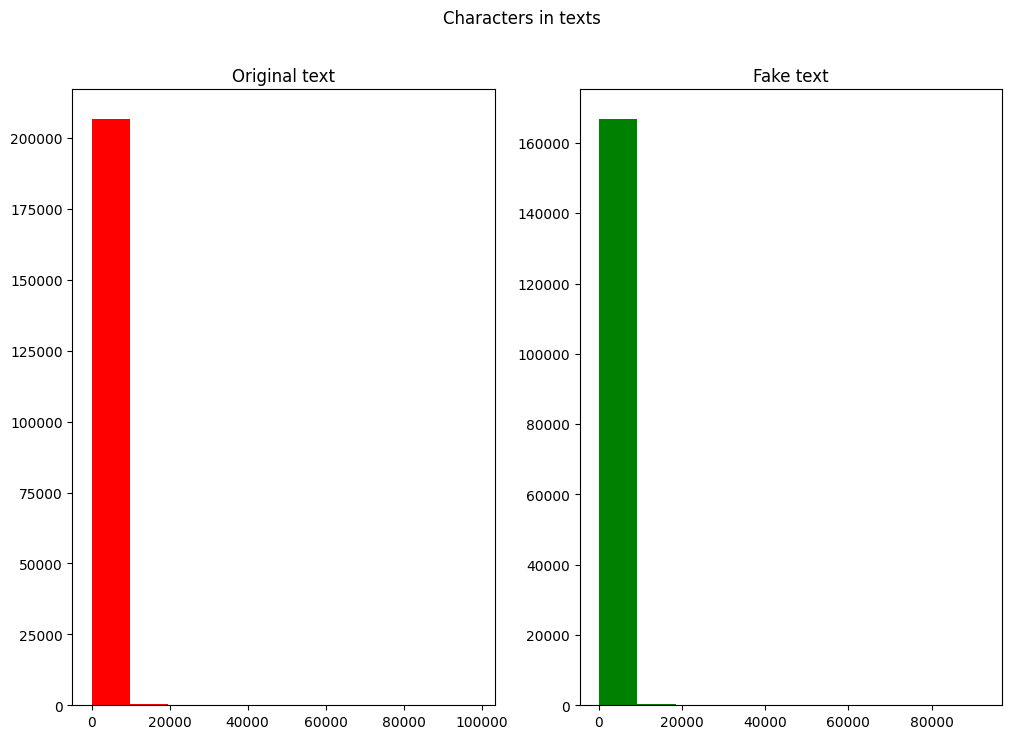

In [24]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,8))
text_len=df[df['label_binary']==1]['text'].str.len()
ax1.hist(text_len,color='red')
ax1.set_title('Original text')
text_len=df[df['label_binary']==0]['text'].str.len()
ax2.hist(text_len,color='green')
ax2.set_title('Fake text')
fig.suptitle('Characters in texts')
plt.show()

**Number of words in each text**

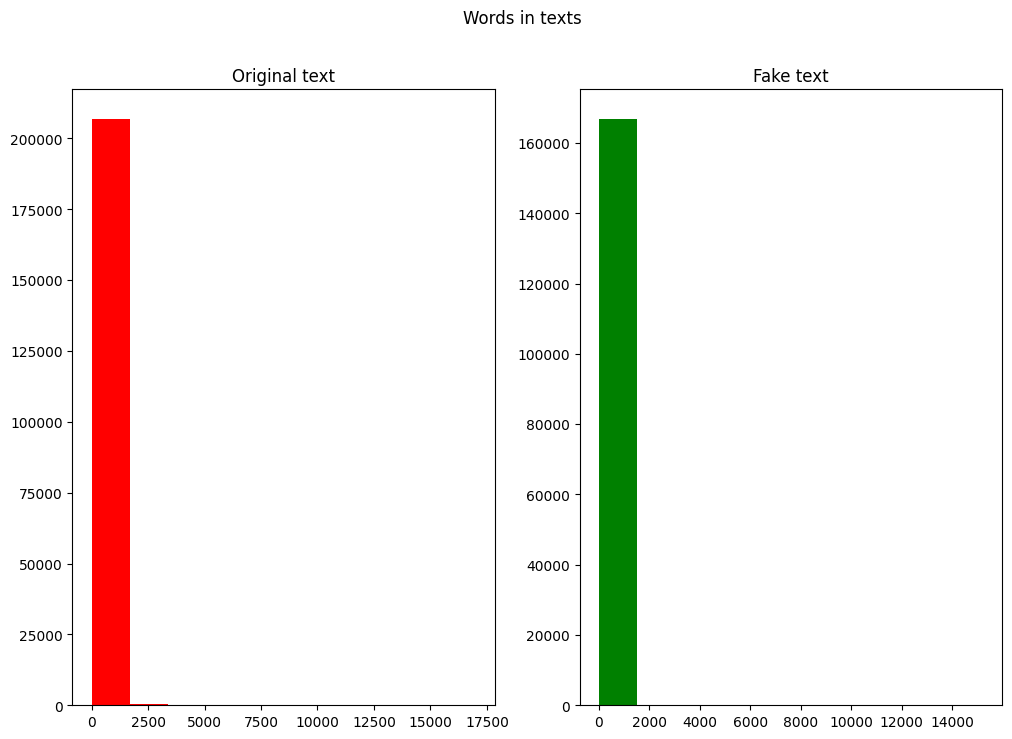

In [25]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,8))
text_len=df[df['label_binary']==1]['text'].str.split().map(lambda x: len(x))
ax1.hist(text_len,color='red')
ax1.set_title('Original text')
text_len=df[df['label_binary']==0]['text'].str.split().map(lambda x: len(x))
ax2.hist(text_len,color='green')
ax2.set_title('Fake text')
fig.suptitle('Words in texts')
plt.show()

**Average word length in a text**

Text(0.5, 0.98, 'Average word length in each text')

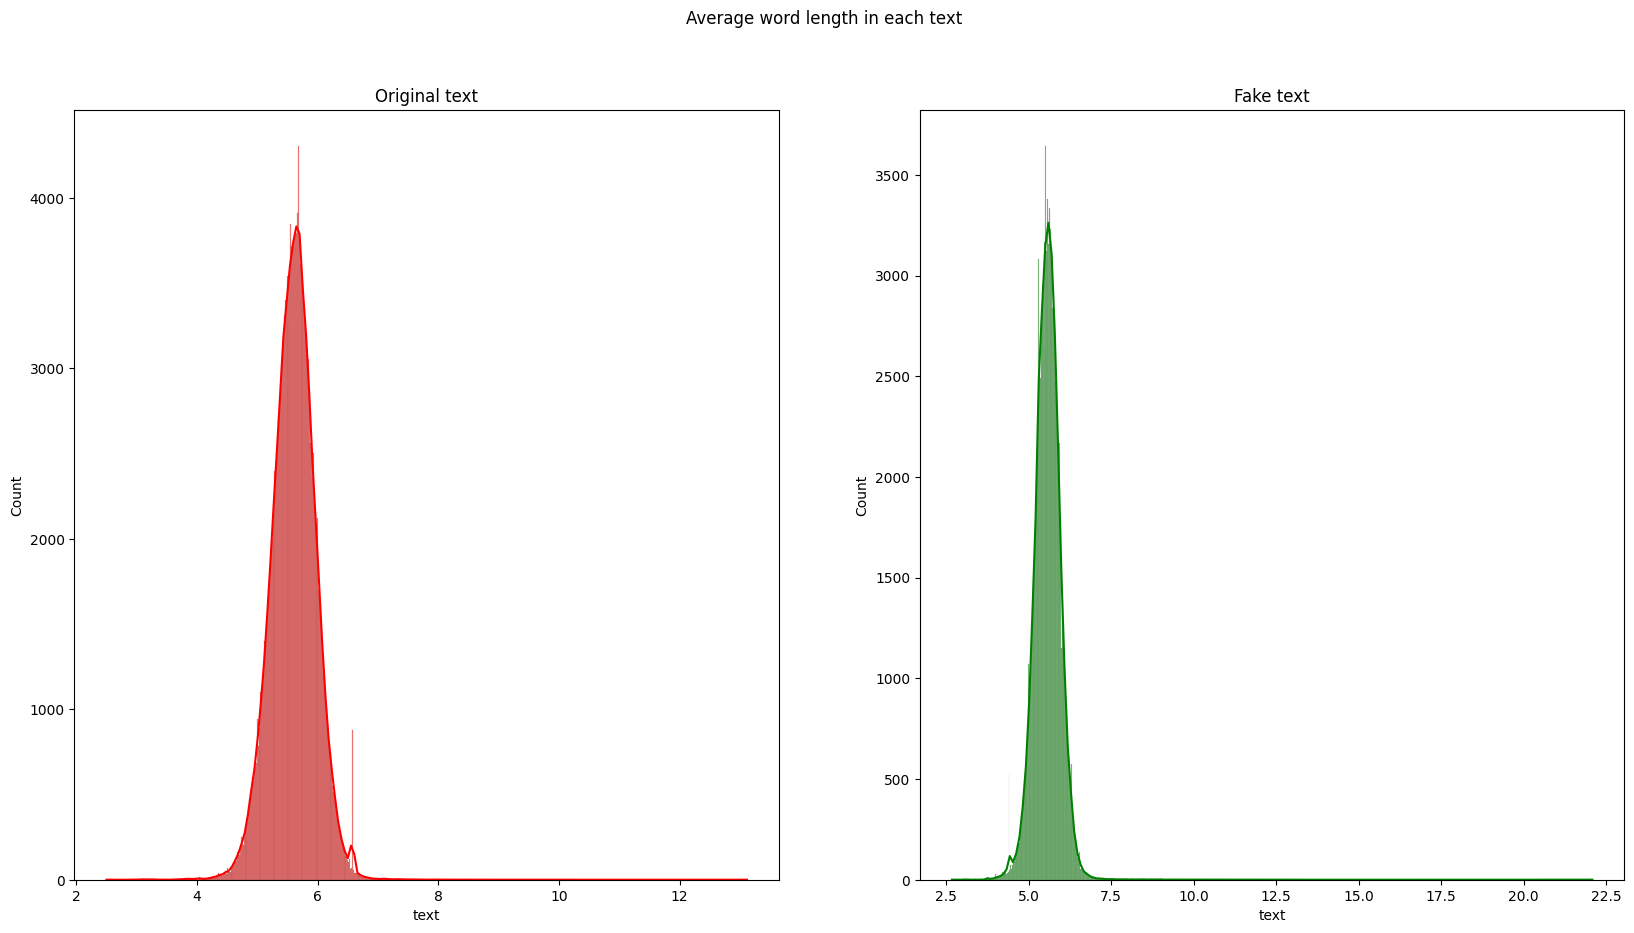

In [26]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(20,10))
word=df[df['label_binary']==1]['text'].str.split().apply(lambda x : [len(i) for i in x])
sns.histplot(word.map(lambda x: np.mean(x)), ax=ax1, color='red', kde=True)
ax1.set_title('Original text')
word=df[df['label_binary']==0]['text'].str.split().apply(lambda x : [len(i) for i in x])
sns.histplot(word.map(lambda x: np.mean(x)), ax=ax2, color='green', kde=True)
ax2.set_title('Fake text')
fig.suptitle('Average word length in each text')

In [27]:
def get_corpus(text):
    words = []
    for i in text:
        for j in i.split():
            words.append(j.strip())
    return words
corpus = get_corpus(df.text)
corpus[:8]

['يخوض', 'المنتخب', 'الوطني', 'المغربي', 'لكرة', 'القدم', 'لأقل', '20']

In [28]:
from collections import Counter
counter = Counter(corpus)
most_common = counter.most_common(10)
most_common = dict(most_common)
most_common

{'خلال': 277852,
 'اليوم': 192239,
 'رئيس': 149198,
 'أنه': 148395,
 '،': 143342,
 'تم': 130307,
 '-': 109532,
 '–': 106709,
 'العام': 105462,
 'محمد': 104721}

In [29]:
x_train,x_test,y_train,y_test = train_test_split(df.text,df.label_binary,
                                                 test_size=0.2,shuffle=True,
                                                 random_state = 0)

In [30]:
len(x_train), len(y_train), len(x_test), len(y_test)

(299634, 299634, 74909, 74909)

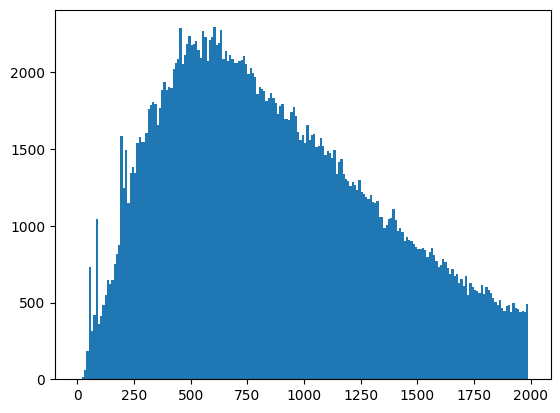

In [31]:
totalNumWords = [len(one_comment) for one_comment in x_train]
plt.hist(totalNumWords,bins = np.arange(0,2000,10))
plt.show()

In [32]:
max_features = 15000
maxlen = 250

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(x_train)
tokenized_train = tokenizer.texts_to_sequences(x_train)
x_train = sequence.pad_sequences(tokenized_train, maxlen=maxlen)

In [34]:
tokenized_test = tokenizer.texts_to_sequences(x_test)
X_test = sequence.pad_sequences(tokenized_test, maxlen=maxlen)

In [35]:
X_test[-11]

array([ 6007,   209,     8,   624,   163,  2537,  4193,   728,   210,
         272,  1582,   145, 14671,   274,  4360, 12499,   274, 13639,
         772,  1399,   449,     2,  4959,   664,  1112,  2875,  3060,
        5819,   154, 12311,  1635,   163,    65,  1554,   221,   303,
         932,  7470,  3890,  6962, 11648,    69, 14790,  9046,    68,
       10968,  3060,  5819, 10968,  7470,  3890,  6962, 11648,     2,
       12213, 12213,   114,   139,   114,    57, 14779,   114,    51,
         114,    85,  6628,  2360,   772,  1034,  6628,  2360, 12524,
       11649, 12311,  7173,  6628,  2360, 12311,  3563,  1137,  2946,
        6628,   591,  1582,   145,  4306,   221,   490,   154,    85,
          44,    17,   337,    11,    44,    17, 14779,  1280,  4360,
        4636,   221,   285,   154,   248,    44,    17,   321,    44,
          17, 12213,  1280,  4360,  1199,  3319,    18,   226,   154,
         208,    44,    11,    17, 12213,   154,   501,   612,   474,
        6866,   728,

In [36]:
EMBEDDING_FILE = 'glove.twitter.27B.100d.txt'

In [37]:
def get_coefs(word, *arr): 
    return word, np.asarray(arr, dtype='float32')

with open(EMBEDDING_FILE, encoding='utf-8') as f:
    embeddings_index = dict(get_coefs(*o.rstrip().rsplit(' ')) for o in f)


In [38]:
all_embs = np.stack(list(embeddings_index.values()))
emb_mean, emb_std = all_embs.mean(), all_embs.std()
embed_size = all_embs.shape[1]

word_index = tokenizer.word_index
nb_words = min(max_features, len(word_index))
embedding_matrix = np.random.normal(emb_mean, emb_std, (nb_words, embed_size))

for word, i in word_index.items():
    if i >= max_features:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [39]:
batch_size = 256 
epochs = 12
embed_size = 100

In [40]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.5, min_lr=0.00001)

In [37]:
# TRAINING THE MODEL

In [41]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
#Defining Neural Network
model = Sequential()
#Non-trainable embeddidng layer
model.add(Embedding(max_features, output_dim=embed_size, weights=[embedding_matrix],  trainable=False))
#LSTM 
model.add(GRU(units=256 , return_sequences = True , recurrent_dropout = 0.3))
model.add(GRU(units=128 , recurrent_dropout = 0.25 , dropout = 0.25))
model.add(Dense(units = 64 , activation = 'relu'))
model.add(Dense(units = 32 , activation = 'relu'))
model.add(Dense(1, activation='sigmoid'))

In [42]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │       1,500,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,000 (5.72 MB)

In [44]:
from keras.utils import plot_model

model.build(input_shape=(None, 100))

# Visualize model architecture
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [45]:
history = model.fit(x_train, y_train, batch_size = batch_size, validation_split=0.2, epochs=epochs, callbacks = [learning_rate_reduction])

Epoch 1/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 3025s 3s/step - accuracy: 0.6185 - loss: 0.6266 - val_accuracy: 0.6867 - val_loss: 0.5614 - learning_rate: 0.0010
Epoch 2/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 2768s 3s/step - accuracy: 0.6922 - loss: 0.5286 - val_accuracy: 0.7861 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 3/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 2654s 3s/step - accuracy: 0.7946 - loss: 0.3762 - val_accuracy: 0.8174 - val_loss: 0.3411 - learning_rate: 0.0010
Epoch 4/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 2625s 3s/step - accuracy: 0.8196 - loss: 0.3358 - val_accuracy: 0.8299 - val_loss: 0.3190 - learning_rate: 0.0010
Epoch 5/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 2646s 3s/step - accuracy: 0.8353 - loss: 0.3113 - val_accuracy: 0.8383 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 6/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 2601s 3s/step - accuracy: 0.8483 - loss: 0.2932 - val_accuracy: 0.8432 - val_loss: 0.2972 - learning_rate: 0.0010
Epoch 7/12
937/937 ━━━━━━━━━━━━━━━━━━━━ 2589s 3s/step - accuracy: 0.8586 - l

# ANALYSIS AFTER TRAINING OF MODEL


In [46]:
print("Accuracy of the model on Training Data is - " , model.evaluate(x_train,y_train)[1]*100 , "%")
print("Accuracy of the model on Testing Data is - " , model.evaluate(X_test,y_test)[1]*100 , "%")

9364/9364 ━━━━━━━━━━━━━━━━━━━━ 2538s 271ms/step - accuracy: 0.9122 - loss: 0.1885
Accuracy of the model on Training Data is -  90.19570350646973 %
2341/2341 ━━━━━━━━━━━━━━━━━━━━ 705s 301ms/step - accuracy: 0.8604 - loss: 0.2861
Accuracy of the model on Testing Data is -  85.72401404380798 %


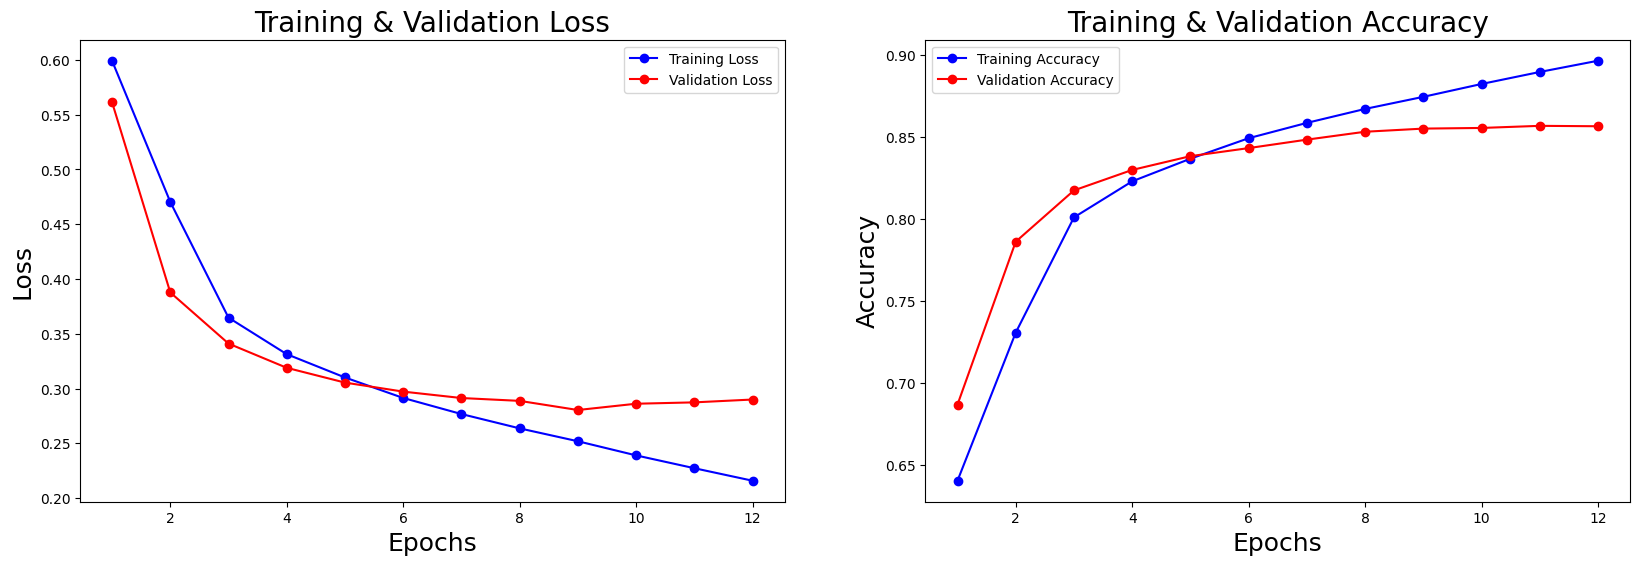

In [48]:
fig, ax = plt.subplots(1,2)
fig.set_size_inches(20,6)

epochs = [i for i in range(1, len(train_loss)+1)]
train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

ax[0].plot(epochs, train_loss, 'bo-', label='Training Loss')
ax[0].plot(epochs, val_loss, 'ro-', label='Validation Loss')
ax[0].set_xlabel('Epochs', fontsize=18)
ax[0].set_ylabel('Loss', fontsize=18)
ax[0].set_title('Training & Validation Loss', fontsize=20)
ax[0].legend()

ax[1].plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
ax[1].plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
ax[1].set_xlabel('Epochs', fontsize=18)
ax[1].set_ylabel('Accuracy', fontsize=18)
ax[1].set_title('Training & Validation Accuracy', fontsize=20)
ax[1].legend()

In [52]:
import numpy as np

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)



2341/2341 ━━━━━━━━━━━━━━━━━━━━ 666s 283ms/step


In [53]:
print(classification_report(y_test, predicted_classes, target_names = ['Fake','Not Fake']))

              precision    recall  f1-score   support

        Fake       0.45      1.00      0.62     33873
    Not Fake       0.00      0.00      0.00     41036

    accuracy                           0.45     74909
   macro avg       0.23      0.50      0.31     74909
weighted avg       0.20      0.45      0.28     74909



D:\Student\anaconda3\envs\FakeNews\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Student\anaconda3\envs\FakeNews\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Student\anaconda3\envs\FakeNews\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

Text(70.72222222222221, 0.5, 'Actual')

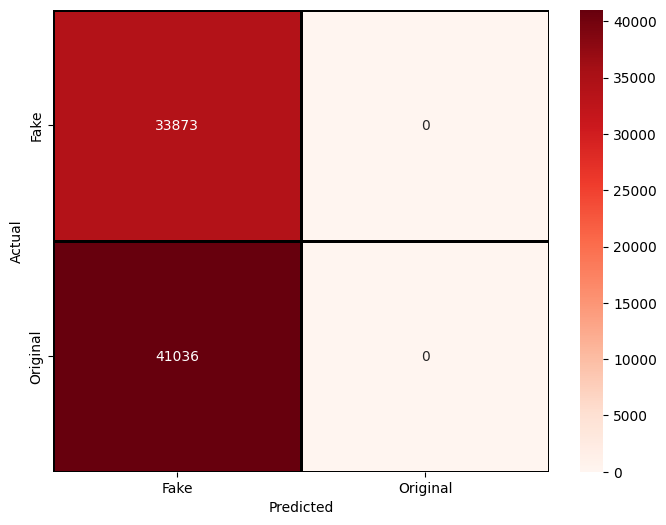

In [54]:
cm = confusion_matrix(y_test,predicted_classes)
cm = pd.DataFrame(cm , index = ['Fake','Original'] , columns = ['Fake','Original'])
plt.figure(figsize = (8,6))
sns.heatmap(cm,cmap= "Reds", linecolor = 'black' , linewidth = 1 , annot = True, fmt='' , xticklabels = ['Fake','Original'] , yticklabels = ['Fake','Original'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

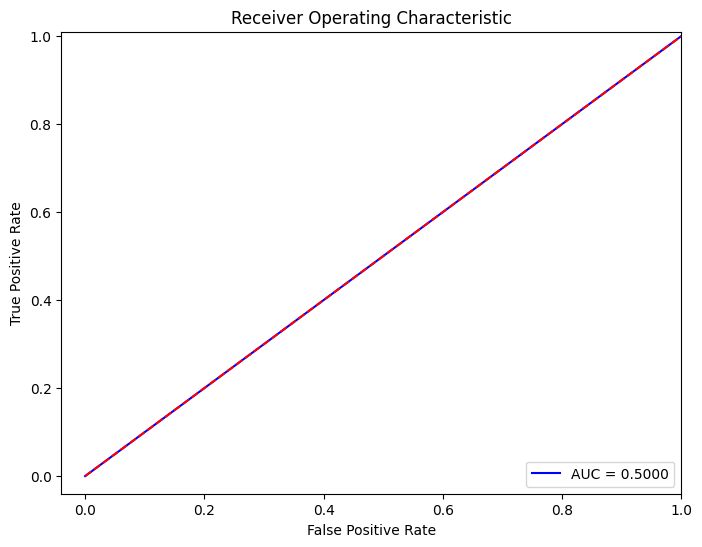

In [55]:
fpr, tpr, thresholds = roc_curve(y_test,predicted_classes)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',label='AUC = %0.4f'% roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.04,1.0])
plt.ylim([-0.04,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc='lower right')
plt.show()

In [62]:
df['text']

0         يخوض المنتخب الوطني المغربي لكرة القدم لأقل 20...
1         ترأس عبد القادر اعمارة، وزير التجهيز النقل الل...
2         أكد النجم الارجنتيني ليونيل ميسي فوز فريقه برش...
3         أكّد الدبلوماسي المغربي السابق بإسبانيا، عبد ا...
4         أعلنت شركتا سانوفي الفرنسية العملاقة تصنيع الأ...
                                ...                        
606907    شدد مسؤول إيطالي اليوم الأربعاء ضرورة التزام ا...
606908    حذّر مركز الأزهر العالمي للفتوى الإلكرتونية، ل...
606909    دافع الرئيس الروسي فلاديمير بوتين استضافة مدين...
606910    شعرت المستشارة الألمانية أنجيلا ميركل "بخيبة أ...
606911    انتهى مشوار أرتيم بيسيدين لاعب المنتخب الأوكرا...
Name: text, Length: 374543, dtype: object

# K-Fold part

In [67]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df['text']
y = df['label_binary']

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X)
tokenized_train = tokenizer.texts_to_sequences(X)
X = pad_sequences(tokenized_train, maxlen=maxlen)


from sklearn.model_selection import KFold
# Define the k-fold cross-validation iterator
kfold = KFold(n_splits=5, shuffle=True, random_state=1)


In [74]:
# Initialize a list to store the scores for each fold
import numpy as np
import tensorflow as tf

# Ensure inputs are NumPy arrays
X = np.array(X)
y = np.array(y)

# Compile the model before using it
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Initialize a list to store the scores for each fold
allscores = []

for train, test in kfold.split(X, y):
    # Fit the model on the training data
    model.fit(X[train], y[train], batch_size=batch_size, epochs=10, validation_split=0.001, verbose=1)

    # Evaluate the model on the test data
    scores = model.evaluate(X[test], y[test], verbose=0)
    print(f'Test loss: {scores[0]}')
    print(f'Test accuracy: {scores[1]}')
    
    allscores.append(scores[1])


Epoch 1/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 3866s 3s/step - accuracy: 0.7121 - loss: 0.5042 - val_accuracy: 0.7533 - val_loss: 0.5506
Epoch 2/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 3593s 3s/step - accuracy: 0.8058 - loss: 0.3555 - val_accuracy: 0.8167 - val_loss: 0.4686
Epoch 3/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 3732s 3s/step - accuracy: 0.8295 - loss: 0.3225 - val_accuracy: 0.7700 - val_loss: 0.5253
Epoch 4/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 4006s 3s/step - accuracy: 0.8466 - loss: 0.2948 - val_accuracy: 0.8100 - val_loss: 0.4719
Epoch 5/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 4055s 3s/step - accuracy: 0.8592 - loss: 0.2748 - val_accuracy: 0.8600 - val_loss: 0.4191
Epoch 6/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 4275s 4s/step - accuracy: 0.8692 - loss: 0.2604 - val_accuracy: 0.8067 - val_loss: 0.4268
Epoch 7/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 4352s 4s/step - accuracy: 0.8782 - loss: 0.2455 - val_accuracy: 0.8367 - val_loss: 0.4196
Epoch 8/10
1170/1170 ━━━━━━━━━━━━━━━━━━━━ 4326s 4s/step - accuracy: 0.8881 -

In [ ]:
# Calculate the mean and standard deviation of the scores
mean_score = np.mean(allscores)
std_dev = np.std(allscores)

print(f'Mean Test accuracy: {mean_score}')
print(f'Standard deviation: {std_dev}')